# Assignment 2: Bag-of-Words and Word2Vec Embeddings

**Problem Statement:** Perform bag-of-words approach (count occurrence, normalized count occurrence), TF-IDF on data. Create embeddings using Word2Vec.

**Dataset:** [Car Features and MSRP Dataset from Kaggle](https://www.kaggle.com/datasets/CooperUnion/cardataset)

**Download Instructions:**
1. Go to https://www.kaggle.com/datasets/CooperUnion/cardataset
2. Download the dataset (data.csv)
3. Place it in the same directory as this notebook

## 1. Import Required Libraries

In [1]:
# Install required packages
!pip install pandas numpy scikit-learn gensim matplotlib seaborn nltk -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from gensim.models import Word2Vec
import nltk
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt', quiet=True)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Load and Explore Dataset

In [ ]:
df = pd.read_csv('data.csv')

print(f"\nDataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
display(df.head())

print(f"\nColumn names:")
print(df.columns.tolist())

print(f"\nDataset info:")
df.info()

✓ Loaded actual car dataset from data.csv

Dataset shape: (11914, 16)

First 5 rows:


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500



Column names:
['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP', 'Engine Cylinders', 'Transmission Type', 'Driven_Wheels', 'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style', 'highway MPG', 'city mpg', 'Popularity', 'MSRP']

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   str    
 10  Vehicle Size       11914 non-null  str    
 11  Vehicl

## 3. Create Text Documents from Car Features

In [3]:
# Combine relevant text features into documents
def create_car_document(row):
    """Combine car features into a text document"""
    doc_parts = [
        str(row['Make']),
        str(row['Model']),
        str(row['Engine Fuel Type']),
        str(row['Transmission Type']),
        str(row['Driven_Wheels']),
        str(row['Vehicle Size']),
        str(row['Vehicle Style'])
    ]
    
    # Add Market Category if available
    if 'Market Category' in df.columns and pd.notna(row.get('Market Category')):
        doc_parts.append(str(row['Market Category']))
    
    return ' '.join(doc_parts).lower()

# Create text documents
df['text_document'] = df.apply(create_car_document, axis=1)

print("Sample text documents:")
for i in range(5):
    print(f"\nDocument {i+1}: {df['text_document'].iloc[i]}")

# Create corpus
corpus = df['text_document'].tolist()
print(f"\n✓ Created corpus with {len(corpus)} documents")

Sample text documents:

Document 1: bmw 1 series m premium unleaded (required) manual rear wheel drive compact coupe factory tuner,luxury,high-performance

Document 2: bmw 1 series premium unleaded (required) manual rear wheel drive compact convertible luxury,performance

Document 3: bmw 1 series premium unleaded (required) manual rear wheel drive compact coupe luxury,high-performance

Document 4: bmw 1 series premium unleaded (required) manual rear wheel drive compact coupe luxury,performance

Document 5: bmw 1 series premium unleaded (required) manual rear wheel drive compact convertible luxury

✓ Created corpus with 11914 documents


## 4. Bag-of-Words: Count Occurrence

In [4]:
# Create Count Vectorizer (Bag-of-Words)
count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(corpus)

# Get feature names (vocabulary)
feature_names = count_vectorizer.get_feature_names_out()

print("="*80)
print("BAG-OF-WORDS: COUNT OCCURRENCE")
print("="*80)
print(f"Vocabulary size: {len(feature_names)}")
print(f"Matrix shape: {count_matrix.shape}")
print(f"Matrix type: {type(count_matrix)}")
print(f"Sparsity: {(1 - count_matrix.nnz / (count_matrix.shape[0] * count_matrix.shape[1])):.2%}")

# Convert to DataFrame
count_df = pd.DataFrame(
    count_matrix.toarray(), 
    columns=feature_names
)

print(f"\nVocabulary (all words):")
print(list(feature_names))

print(f"\nCount Matrix (first 5 documents, first 10 features):")
display(count_df.iloc[:5, :10])

BAG-OF-WORDS: COUNT OCCURRENCE
Vocabulary size: 845
Matrix shape: (11914, 845)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Sparsity: 98.53%

Vocabulary (all words):
['10', '100', '124', '12c', '15', '150', '1500', '1500hd', '16', '190', '200', '200h', '200sx', '200t', '240', '240sx', '250', '2500', '250h', '2dr', '2x', '300', '3000gt', '300h', '300m', '300zx', '323', '330', '350', '350z', '360', '370z', '400', '400h', '420', '430', '450', '450h', '456m', '458', '460', '470', '4c', '4dr', '4runner', '4x', '50', '500', '500e', '500l', '500x', '550', '560', '57', '570', '570s', '575m', '599', '600', '6000', '600h', '612', '62', '626', '650s', '718', '740', '760', '780', '7x', '80', '850', '86', '90', '900', '9000', '911', '928', '929', '940', '944', '960', '968', 'a3', 'a4', 'a5', 'a6', 'a7', 'a8', 'acadia', 'accent', 'acclaim', 'accord', 'achieva', 'activehybrid', 'acura', 'aerio', 'aerostar', 'alero', 'alfa', 'all', 'allante', 'allroad', 'alltrack', 'alpina', 'altima', 'am', 'am

,10,100,124,12c,15,150,1500,1500hd,16,190
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0


### 4.1 Visualize Word Frequencies

Top 20 Most Frequent Words:
drive          11917
wheel          11914
unleaded       11689
automatic       8266
regular         7564
front           4787
compact         4764
midsize         4373
premium         3612
performance     3501
rear            3371
luxury          3288
4dr             3190
sedan           3077
manual          2935
large           2777
suv             2655
hatchback       2416
all             2353
flex            2200
dtype: int64


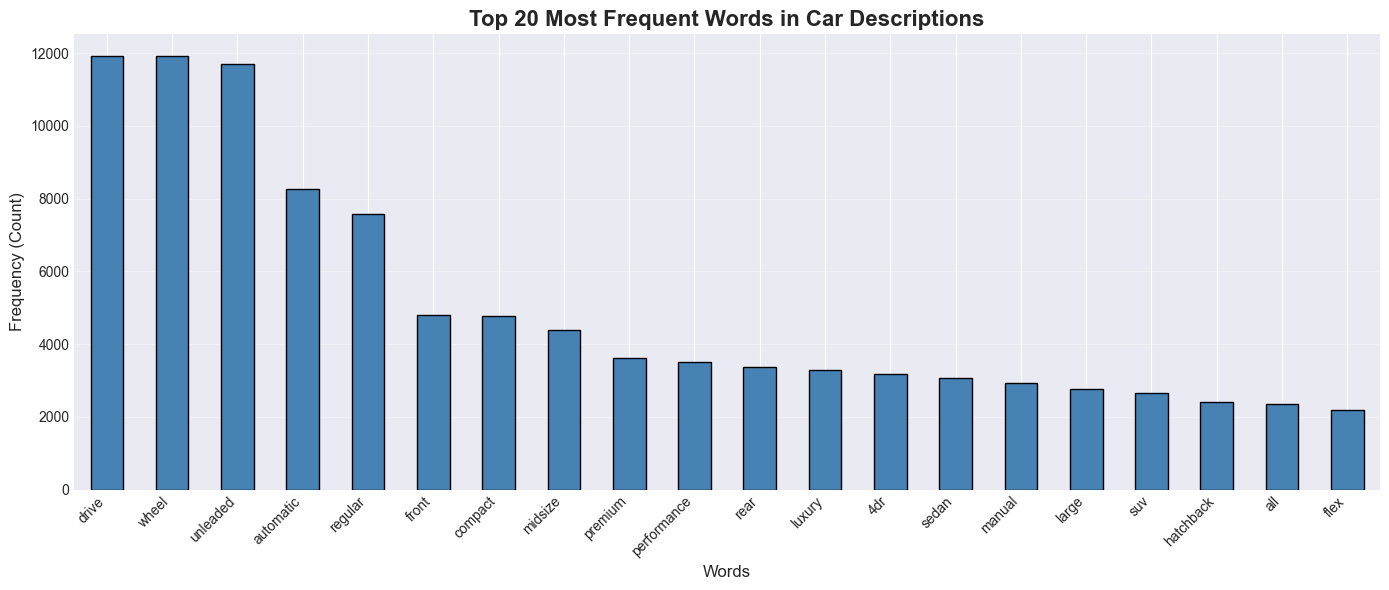

In [5]:
# Calculate word frequencies
word_freq = count_df.sum(axis=0).sort_values(ascending=False)

print("Top 20 Most Frequent Words:")
print(word_freq.head(20))

# Plot
plt.figure(figsize=(14, 6))
word_freq.head(20).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 20 Most Frequent Words in Car Descriptions', fontsize=16, fontweight='bold')
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Bag-of-Words: Normalized Count Occurrence

In [6]:
# Normalize using L1 normalization (each row sums to 1)
normalized_count_matrix = normalize(count_matrix, norm='l1', axis=1)

# Convert to DataFrame
normalized_count_df = pd.DataFrame(
    normalized_count_matrix.toarray(),
    columns=feature_names
)

print("="*80)
print("BAG-OF-WORDS: NORMALIZED COUNT OCCURRENCE")
print("="*80)
print(f"Normalized Count Matrix (first 5 documents, first 10 features):")
display(normalized_count_df.iloc[:5, :10])

# Verify normalization (each row should sum to 1)
print(f"\nRow sums (should all be 1.0):")
print(normalized_count_df.sum(axis=1).head(10))

# Compare raw counts vs normalized
print(f"\nComparison for Document 0:")
comparison_df = pd.DataFrame({
    'Word': feature_names[:10],
    'Raw Count': count_df.iloc[0, :10].values,
    'Normalized': normalized_count_df.iloc[0, :10].values
})
display(comparison_df)

BAG-OF-WORDS: NORMALIZED COUNT OCCURRENCE
Normalized Count Matrix (first 5 documents, first 10 features):


,10,100,124,12c,15,150,1500,1500hd,16,190
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Row sums (should all be 1.0):
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
5    1.0
6    1.0
7    1.0
8    1.0
9    1.0
dtype: float64

Comparison for Document 0:


,Word,Raw Count,Normalized
0,10,0,0.0
1,100,0,0.0
2,124,0,0.0
3,12c,0,0.0
4,15,0,0.0
5,150,0,0.0
6,1500,0,0.0
7,1500hd,0,0.0
8,16,0,0.0
9,190,0,0.0


### 5.1 Visualize Normalized vs Raw Counts

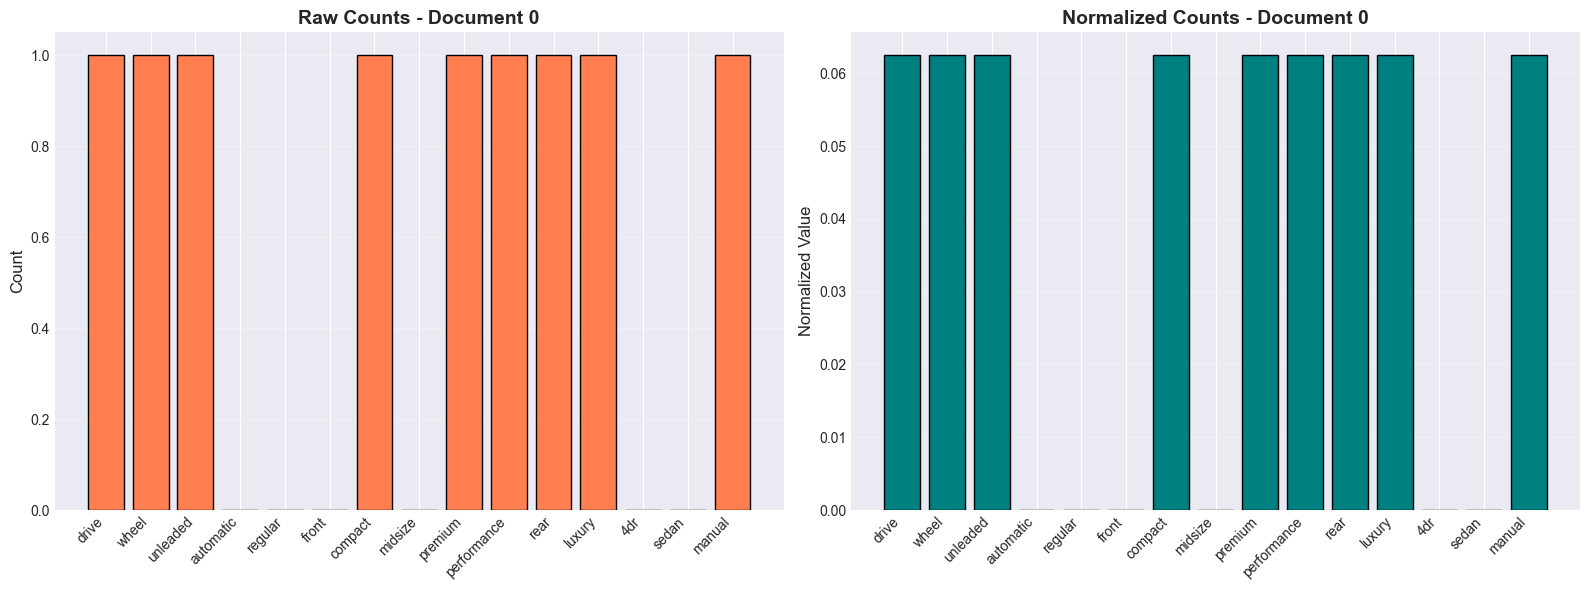

In [7]:
# Compare raw and normalized counts for a sample document
doc_idx = 0
sample_words = word_freq.head(15).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
raw_vals = count_df.loc[doc_idx, sample_words]
axes[0].bar(range(len(sample_words)), raw_vals, color='coral', edgecolor='black')
axes[0].set_xticks(range(len(sample_words)))
axes[0].set_xticklabels(sample_words, rotation=45, ha='right')
axes[0].set_title(f'Raw Counts - Document {doc_idx}', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Normalized counts
norm_vals = normalized_count_df.loc[doc_idx, sample_words]
axes[1].bar(range(len(sample_words)), norm_vals, color='teal', edgecolor='black')
axes[1].set_xticks(range(len(sample_words)))
axes[1].set_xticklabels(sample_words, rotation=45, ha='right')
axes[1].set_title(f'Normalized Counts - Document {doc_idx}', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Normalized Value', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. TF-IDF (Term Frequency - Inverse Document Frequency)

In [8]:
# Create TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

# Get feature names
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print("="*80)
print("TF-IDF REPRESENTATION")
print("="*80)
print(f"Matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(tfidf_feature_names)}")
print(f"Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])):.2%}")

# Convert to DataFrame
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_feature_names
)

print(f"\nTF-IDF Matrix (first 5 documents, first 10 features):")
display(tfidf_df.iloc[:5, :10])

TF-IDF REPRESENTATION
Matrix shape: (11914, 845)
Vocabulary size: 845
Sparsity: 98.53%

TF-IDF Matrix (first 5 documents, first 10 features):


,10,100,124,12c,15,150,1500,1500hd,16,190
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 6.1 Analyze TF-IDF Scores

In [9]:
# Get top TF-IDF words for sample documents
def get_top_tfidf_words(doc_index, n=5):
    """Get top n words with highest TF-IDF scores for a document"""
    scores = tfidf_df.iloc[doc_index]
    top_words = scores.nlargest(n)
    return top_words

print("Top 5 Important Words (by TF-IDF) for Sample Documents:\n")
for i in range(min(5, len(df))):
    print(f"Document {i}: {df['text_document'].iloc[i][:60]}...")
    top_words = get_top_tfidf_words(i, n=5)
    for word, score in top_words.items():
        if score > 0:
            print(f"  {word}: {score:.4f}")
    print()

Top 5 Important Words (by TF-IDF) for Sample Documents:

Document 0: bmw 1 series m premium unleaded (required) manual rear wheel...
  bmw: 0.3970
  series: 0.3865
  factory: 0.3432
  tuner: 0.3432
  coupe: 0.2824

Document 1: bmw 1 series premium unleaded (required) manual rear wheel d...
  bmw: 0.4706
  series: 0.4582
  convertible: 0.3781
  required: 0.2834
  manual: 0.2471

Document 2: bmw 1 series premium unleaded (required) manual rear wheel d...
  bmw: 0.4540
  series: 0.4421
  coupe: 0.3230
  high: 0.3129
  required: 0.2735

Document 3: bmw 1 series premium unleaded (required) manual rear wheel d...
  bmw: 0.4780
  series: 0.4654
  coupe: 0.3401
  required: 0.2879
  manual: 0.2511

Document 4: bmw 1 series premium unleaded (required) manual rear wheel d...
  bmw: 0.4835
  series: 0.4707
  convertible: 0.3884
  required: 0.2912
  manual: 0.2539



### 6.2 Compare Count, Normalized, and TF-IDF

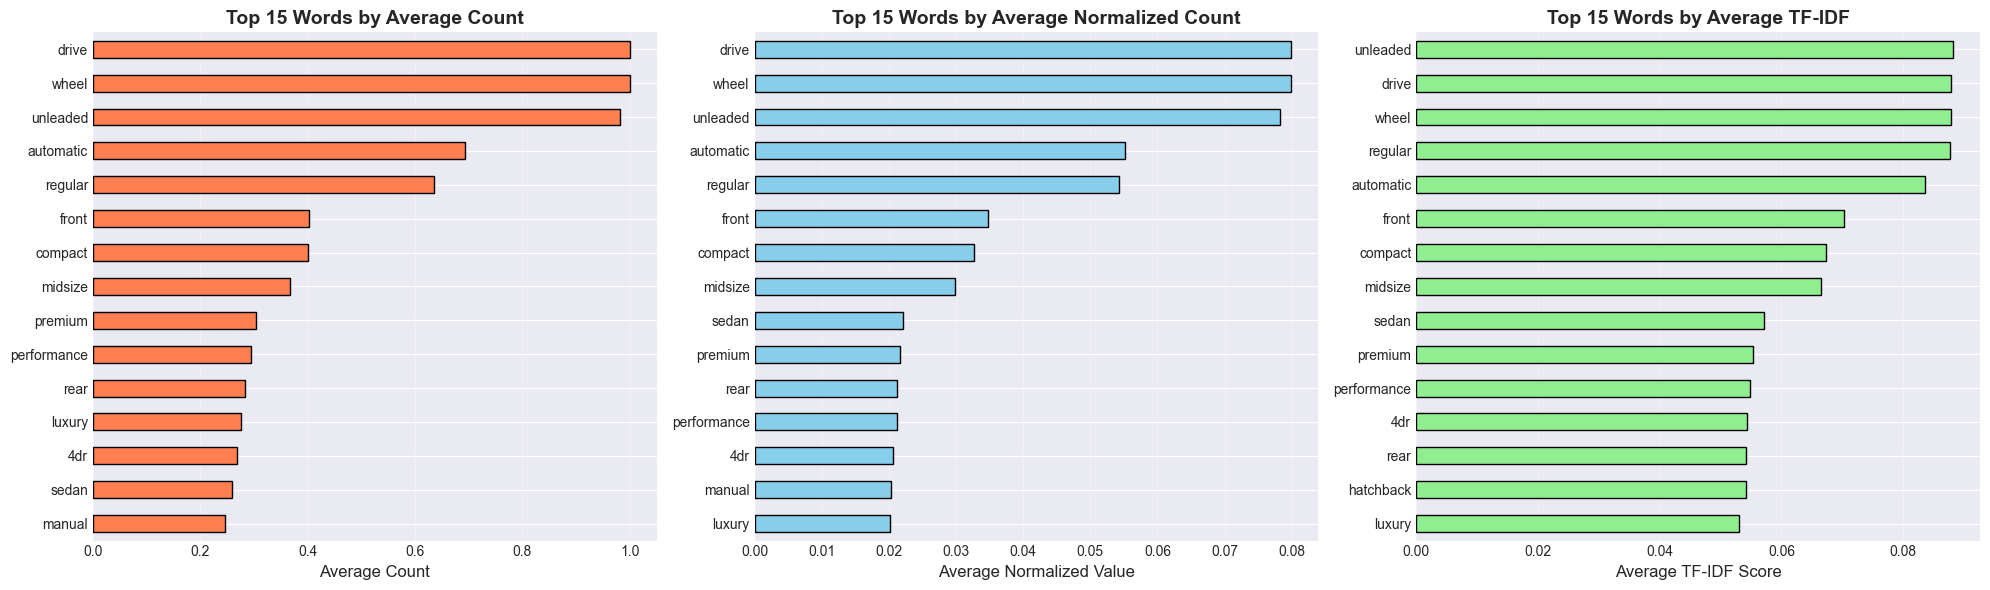


Key Differences:
• Count: Shows raw frequency (common words dominate)
• Normalized: Accounts for document length
• TF-IDF: Weights by uniqueness (distinctive words score higher)


In [10]:
# Calculate average scores across all documents
avg_count = count_df.mean(axis=0).sort_values(ascending=False).head(15)
avg_normalized = normalized_count_df.mean(axis=0).sort_values(ascending=False).head(15)
avg_tfidf = tfidf_df.mean(axis=0).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot Count
avg_count.plot(kind='barh', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Top 15 Words by Average Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Count', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Plot Normalized
avg_normalized.plot(kind='barh', ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title('Top 15 Words by Average Normalized Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Normalized Value', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# Plot TF-IDF
avg_tfidf.plot(kind='barh', ax=axes[2], color='lightgreen', edgecolor='black')
axes[2].set_title('Top 15 Words by Average TF-IDF', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Average TF-IDF Score', fontsize=12)
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Differences:")
print("• Count: Shows raw frequency (common words dominate)")
print("• Normalized: Accounts for document length")
print("• TF-IDF: Weights by uniqueness (distinctive words score higher)")

## 7. Word2Vec Embeddings

### 7.1 Prepare Data for Word2Vec

In [11]:
# Tokenize documents for Word2Vec
tokenized_corpus = [doc.split() for doc in corpus]

print("Tokenized Corpus (first 5 documents):")
for i, tokens in enumerate(tokenized_corpus[:5]):
    print(f"Document {i+1}: {tokens}")

print(f"\nTotal documents: {len(tokenized_corpus)}")
print(f"Average tokens per document: {np.mean([len(doc) for doc in tokenized_corpus]):.2f}")

Tokenized Corpus (first 5 documents):
Document 1: ['bmw', '1', 'series', 'm', 'premium', 'unleaded', '(required)', 'manual', 'rear', 'wheel', 'drive', 'compact', 'coupe', 'factory', 'tuner,luxury,high-performance']
Document 2: ['bmw', '1', 'series', 'premium', 'unleaded', '(required)', 'manual', 'rear', 'wheel', 'drive', 'compact', 'convertible', 'luxury,performance']
Document 3: ['bmw', '1', 'series', 'premium', 'unleaded', '(required)', 'manual', 'rear', 'wheel', 'drive', 'compact', 'coupe', 'luxury,high-performance']
Document 4: ['bmw', '1', 'series', 'premium', 'unleaded', '(required)', 'manual', 'rear', 'wheel', 'drive', 'compact', 'coupe', 'luxury,performance']
Document 5: ['bmw', '1', 'series', 'premium', 'unleaded', '(required)', 'manual', 'rear', 'wheel', 'drive', 'compact', 'convertible', 'luxury']

Total documents: 11914
Average tokens per document: 12.14


### 7.2 Train Word2Vec Model (Skip-gram)

In [12]:
# Train Word2Vec model with Skip-gram architecture
print("Training Word2Vec model...\n")

w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,     # Embedding dimension
    window=5,            # Context window size
    min_count=1,         # Minimum word frequency
    workers=4,           # Number of threads
    sg=1,                # Skip-gram (1) or CBOW (0)
    epochs=100,          # Number of training epochs
    seed=42
)

print("="*80)
print("WORD2VEC MODEL TRAINED (Skip-gram Architecture)")
print("="*80)
print(f"Vocabulary size: {len(w2v_model.wv)}")
print(f"Vector dimension: {w2v_model.wv.vector_size}")
print(f"Training algorithm: Skip-gram")
print(f"Window size: {w2v_model.window}")
print(f"Epochs: {w2v_model.epochs}")
print(f"\nWords in vocabulary:")
print(list(w2v_model.wv.index_to_key))

Training Word2Vec model...

WORD2VEC MODEL TRAINED (Skip-gram Architecture)
Vocabulary size: 952
Vector dimension: 100
Training algorithm: Skip-gram
Window size: 5
Epochs: 100

Words in vocabulary:
['drive', 'wheel', 'unleaded', 'automatic', 'regular', 'front', 'compact', 'midsize', 'premium', 'rear', '4dr', 'sedan', 'manual', 'large', 'suv', 'all', '(required)', 'hatchback', 'pickup', 'cab', '(recommended)', 'four', 'coupe', 'chevrolet', 'crossover', 'flex', 'flex-fuel', 'fuel', 'convertible', '(unleaded/e85)', 'ford', 'luxury', 'volkswagen', 'toyota', 'wagon', 'crew', 'luxury,performance', '2dr', 'dodge', 'automated_manual', 'extended', 'performance', 'nissan', 'passenger', 'gmc', 'minivan', '1500', 'honda', 'factory', 'mazda', 'crossover,luxury', 'cadillac', 'mercedes-benz', 'suzuki', 'luxury,high-performance', 'bmw', 'infiniti', 'audi', 'tuner,luxury,high-performance', 'hyundai', 'hybrid', 'volvo', 'series', 'van', 'exotic,high-performance', 'subaru', 'acura', 'hatchback,performanc

### 7.3 Explore Word Embeddings

In [13]:
# Get vector for specific words
sample_words = ['sedan', 'suv', 'automatic', 'electric', 'luxury']

print("Word Vectors (first 10 dimensions):\n")
for word in sample_words:
    if word in w2v_model.wv:
        vector = w2v_model.wv[word]
        print(f"{word}: {vector[:10]}")
    else:
        print(f"{word}: Not in vocabulary")

# Display full vector for one word
if 'sedan' in w2v_model.wv:
    print(f"\nComplete vector for 'sedan':")
    print(f"Shape: {w2v_model.wv['sedan'].shape}")
    print(f"Vector: {w2v_model.wv['sedan']}")

Word Vectors (first 10 dimensions):

sedan: [-0.21065062  0.49341935  0.6104251  -0.4971885  -0.46610194  0.40745464
  0.8654644   0.21674637 -0.00974717 -0.03707479]
suv: [ 0.3826865  -0.25295633 -0.25254428 -0.23434222 -0.20522365 -0.2820075
 -0.44856596 -0.385784   -0.47987747  0.33314237]
automatic: [ 0.13822661  0.22271274 -0.06796126 -0.29034132  0.0987882   0.19971125
 -0.1992996   0.6270057  -0.34897393 -0.3475963 ]
electric: [-0.35598043  0.19709736 -0.58934605 -0.5612618   0.42922232  0.602979
 -0.36593422  0.8950573   0.06080472 -0.6667632 ]
luxury: [ 0.40451506 -0.42375255 -0.14930664 -0.07553298 -0.6055067   0.96467865
  0.368757    0.3179733   0.94591224 -0.5101744 ]

Complete vector for 'sedan':
Shape: (100,)
Vector: [-0.21065062  0.49341935  0.6104251  -0.4971885  -0.46610194  0.40745464
  0.8654644   0.21674637 -0.00974717 -0.03707479 -0.43890494 -0.19258124
  0.40528363  0.29012933 -0.00563676 -0.19851491 -0.26292232  0.11340149
 -0.08993965 -0.15804583 -0.16242412 -0

### 7.4 Find Similar Words

In [14]:
# Find most similar words
test_words = ['sedan', 'suv', 'automatic', 'electric', 'luxury', 'performance']

print("="*80)
print("WORD SIMILARITY ANALYSIS")
print("="*80)

for word in test_words:
    if word in w2v_model.wv:
        try:
            similar_words = w2v_model.wv.most_similar(word, topn=5)
            print(f"\nWords most similar to '{word}':")
            for similar_word, score in similar_words:
                print(f"  {similar_word}: {score:.4f}")
        except:
            print(f"\nCannot find similar words for '{word}'")
    else:
        print(f"\n'{word}' not in vocabulary")

WORD SIMILARITY ANALYSIS

Words most similar to 'sedan':
  l: 0.4062
  s80: 0.4036
  600h: 0.4034
  q40: 0.3897
  i35: 0.3857

Words most similar to 'suv':
  4dr: 0.5288
  envision: 0.4619
  crossover: 0.4551
  fx50: 0.4392
  crossover,luxury: 0.4346

Words most similar to 'automatic':
  drive: 0.2826
  wheel: 0.2620
  unleaded: 0.2618
  plug-in: 0.2610
  regular: 0.2487

Words most similar to 'electric':
  direct_drive: 0.8723
  ev: 0.7669
  b-class: 0.7127
  exotic,performance: 0.6967
  model: 0.6963

Words most similar to 'luxury':
  luxury,performance: 0.6211
  luxury,high-performance,hybrid: 0.5174
  qx: 0.4550
  sixty: 0.4489
  qx80: 0.4450

Words most similar to 'performance':
  high-performance: 0.5248
  hatchback,performance: 0.5117
  xt: 0.4802
  solara: 0.4693
  performance,hybrid: 0.4604


### 7.5 Word Similarity Scores

In [15]:
# Calculate similarity between word pairs
word_pairs = [
    ('sedan', 'suv'),
    ('automatic', 'manual'),
    ('electric', 'diesel'),
    ('luxury', 'performance'),
    ('compact', 'large'),
    ('coupe', 'convertible')
]

print("\nWord Pair Similarity Scores:")
print(f"{'Word 1':<20} {'Word 2':<20} {'Similarity':<15}")
print("-" * 60)

for word1, word2 in word_pairs:
    if word1 in w2v_model.wv and word2 in w2v_model.wv:
        similarity = w2v_model.wv.similarity(word1, word2)
        print(f"{word1:<20} {word2:<20} {similarity:.4f}")
    else:
        missing = []
        if word1 not in w2v_model.wv:
            missing.append(word1)
        if word2 not in w2v_model.wv:
            missing.append(word2)
        print(f"{word1:<20} {word2:<20} N/A ({', '.join(missing)} not in vocab)")


Word Pair Similarity Scores:
Word 1               Word 2               Similarity     
------------------------------------------------------------
sedan                suv                  -0.0032
automatic            manual               0.1721
electric             diesel               0.2091
luxury               performance          0.1247
compact              large                0.0973
coupe                convertible          0.4608


### 7.6 Visualize Word Embeddings (2D Projection using PCA)

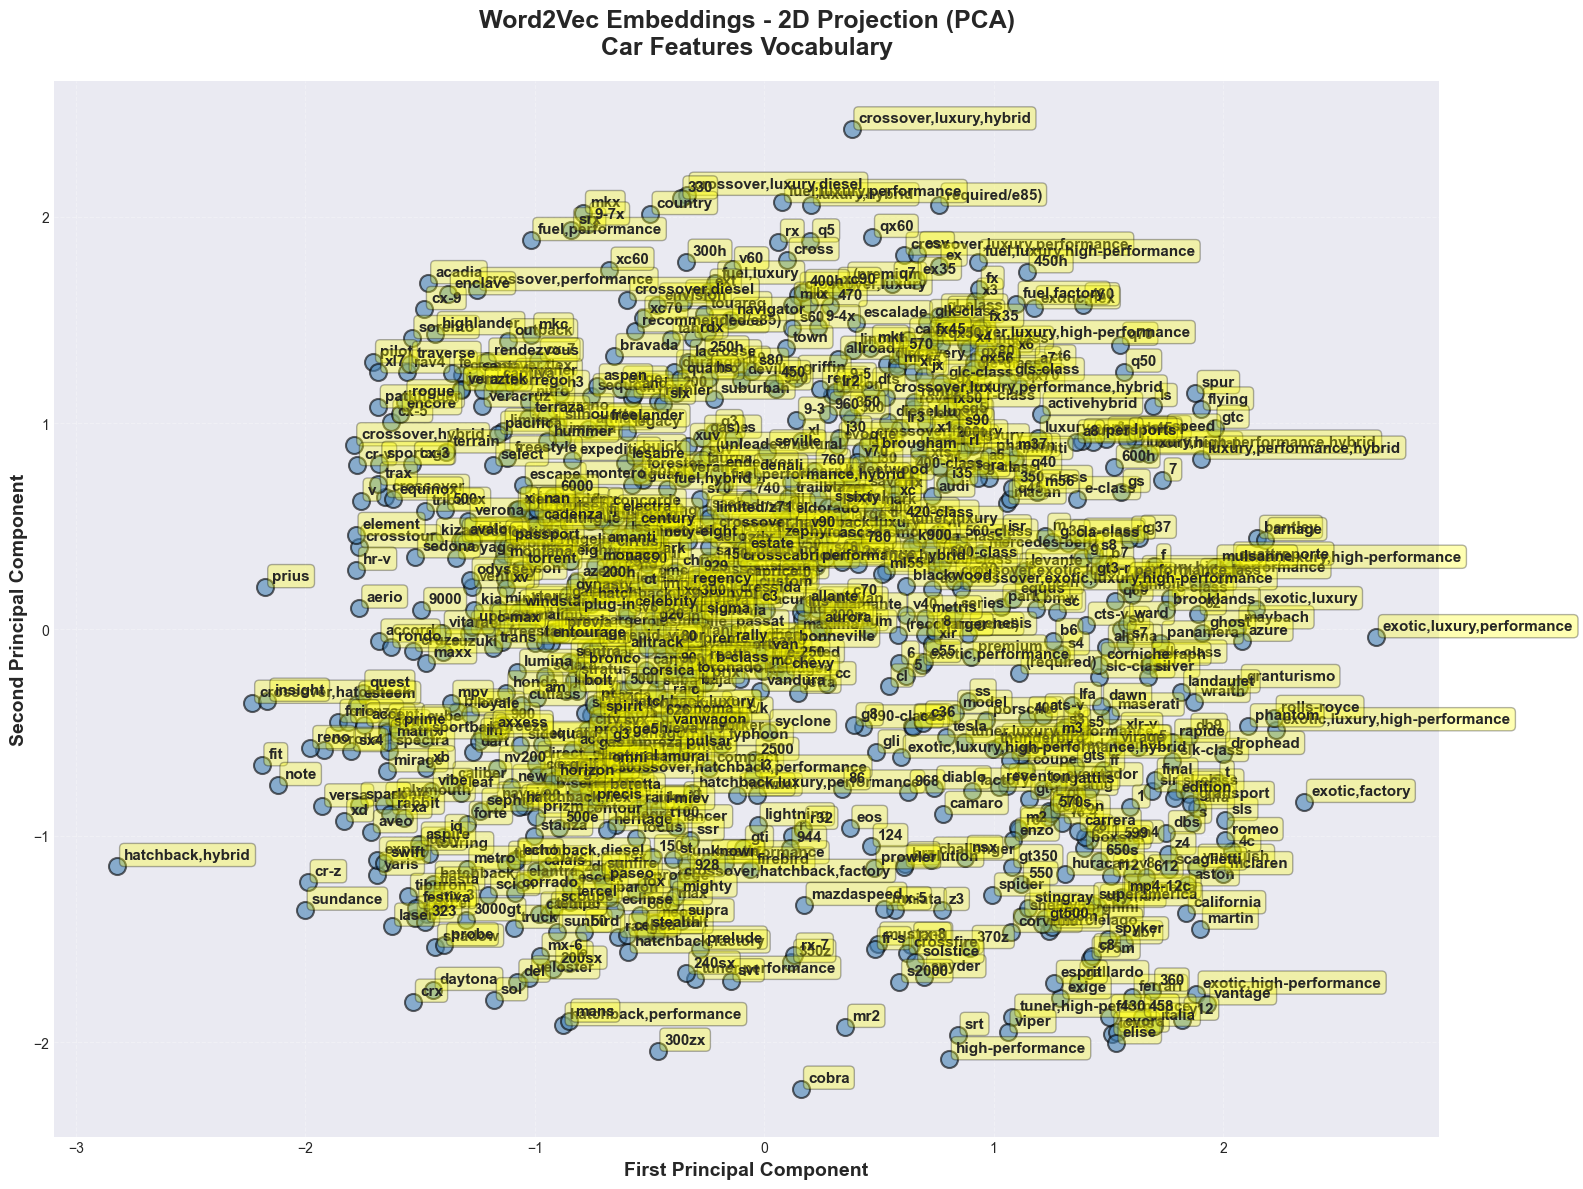


Explained variance ratio: [0.08031952 0.06474342]
Total variance explained: 14.51%


In [16]:
# Get all word vectors
words = list(w2v_model.wv.index_to_key)
word_vectors = np.array([w2v_model.wv[word] for word in words])

# Reduce to 2D using PCA
pca = PCA(n_components=2, random_state=42)
word_vectors_2d = pca.fit_transform(word_vectors)

# Plot
plt.figure(figsize=(16, 12))
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], 
            c='steelblue', s=150, alpha=0.6, edgecolors='black', linewidth=1.5)

# Annotate points with words
for i, word in enumerate(words):
    plt.annotate(word, 
                xy=(word_vectors_2d[i, 0], word_vectors_2d[i, 1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

plt.title('Word2Vec Embeddings - 2D Projection (PCA)\nCar Features Vocabulary', 
         fontsize=18, fontweight='bold', pad=20)
plt.xlabel('First Principal Component', fontsize=14, fontweight='bold')
plt.ylabel('Second Principal Component', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

### 7.7 Word Arithmetic (Analogies)

In [17]:
# Word2Vec can perform word arithmetic
# Example: sedan is to automatic as suv is to ?

print("Word Arithmetic Examples:\n")

# Check if enough words exist for analogies
required_words = ['sedan', 'automatic', 'suv']
if all(word in w2v_model.wv for word in required_words):
    try:
        result = w2v_model.wv.most_similar(
            positive=['suv', 'automatic'], 
            negative=['sedan'], 
            topn=3
        )
        print("sedan is to automatic as suv is to:")
        for word, score in result:
            print(f"  {word} (score: {score:.4f})")
    except:
        print("Not enough training data for analogies")
else:
    print("Required words not in vocabulary for analogies")
    print(f"Available words: {words}")

Word Arithmetic Examples:

sedan is to automatic as suv is to:
  crossover,luxury (score: 0.3366)
  crossover (score: 0.3239)
  xuv (score: 0.3213)


## 8. Comparison Summary

In [18]:
# Create comparison table
comparison_data = {
    'Method': ['Count Vectorizer', 'Normalized Count', 'TF-IDF', 'Word2Vec'],
    'Matrix Type': ['Sparse', 'Sparse', 'Sparse', 'Dense'],
    'Dimensionality': [
        f'{count_matrix.shape[1]} (vocab size)',
        f'{normalized_count_matrix.shape[1]} (vocab size)',
        f'{tfidf_matrix.shape[1]} (vocab size)',
        f'{w2v_model.wv.vector_size} (fixed)'
    ],
    'Captures Semantics': ['No', 'No', 'Partial', 'Yes'],
    'Word Order': ['Ignored', 'Ignored', 'Ignored', 'Considered'],
    'Use Case': [
        'Simple classification',
        'Length-normalized comparison',
        'Information retrieval',
        'Semantic similarity, NLP tasks'
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*100)
print("COMPARISON OF TEXT REPRESENTATION METHODS")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)


COMPARISON OF TEXT REPRESENTATION METHODS
          Method Matrix Type   Dimensionality Captures Semantics Word Order                       Use Case
Count Vectorizer      Sparse 845 (vocab size)                 No    Ignored          Simple classification
Normalized Count      Sparse 845 (vocab size)                 No    Ignored   Length-normalized comparison
          TF-IDF      Sparse 845 (vocab size)            Partial    Ignored          Information retrieval
        Word2Vec       Dense      100 (fixed)                Yes Considered Semantic similarity, NLP tasks


## 9. Summary

In [19]:
summary = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                   TEXT REPRESENTATION TECHNIQUES SUMMARY                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  DATASET INFORMATION:                                                        ║
║  • Total Documents: {len(corpus):,}                                                 ║
║  • Vocabulary Size: {len(feature_names)}                                              ║
║  • Data Source: Car Features Dataset                                         ║
║                                                                              ║
║  TECHNIQUES IMPLEMENTED:                                                     ║
║                                                                              ║
║  1. BAG-OF-WORDS (Count Occurrence)                                         ║
║     ✓ Raw word frequencies in documents                                     ║
║     ✓ Sparse matrix representation                                          ║
║     ✓ Vocabulary: {len(feature_names)} unique words                                  ║
║     ✓ Use: Simple text classification                                       ║
║                                                                              ║
║  2. NORMALIZED BAG-OF-WORDS                                                 ║
║     ✓ L1 normalization (row sums = 1)                                       ║
║     ✓ Accounts for document length variation                                ║
║     ✓ Use: Fair document comparison                                         ║
║                                                                              ║
║  3. TF-IDF                                                                   ║
║     ✓ Weights words by importance                                           ║
║     ✓ TF: Term frequency in document                                        ║
║     ✓ IDF: Inverse document frequency (rarity)                              ║
║     ✓ Use: Information retrieval, search engines                            ║
║                                                                              ║
║  4. WORD2VEC (Skip-gram)                                                     ║
║     ✓ Dense vector embeddings ({w2v_model.wv.vector_size} dimensions)                          ║
║     ✓ Captures semantic relationships                                       ║
║     ✓ Similar words have similar vectors                                    ║
║     ✓ Enables word arithmetic                                               ║
║     ✓ Use: Semantic similarity, deep learning NLP                           ║
║                                                                              ║
║  KEY INSIGHTS:                                                               ║
║  • BoW methods are simple and interpretable                                 ║
║  • TF-IDF highlights distinctive/important words                            ║
║  • Word2Vec captures semantic meaning and context                           ║
║  • Different methods suit different tasks                                   ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

print(summary)


╔══════════════════════════════════════════════════════════════════════════════╗
║                   TEXT REPRESENTATION TECHNIQUES SUMMARY                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  DATASET INFORMATION:                                                        ║
║  • Total Documents: 11,914                                                 ║
║  • Vocabulary Size: 845                                              ║
║  • Data Source: Car Features Dataset                                         ║
║                                                                              ║
║  TECHNIQUES IMPLEMENTED:                                                     ║
║                                                                              ║
║  1. BAG-OF-WORDS (Count Occurrence)                                         ║
║     ✓ Raw word frequencies in documents                                     ║
║     ✓ Sparse matrix representation   

## 10. Save Outputs (Optional)

In [20]:
# Save the outputs
import pickle

# Save Count Matrix
with open('count_matrix.pkl', 'wb') as f:
    pickle.dump(count_matrix, f)

# Save Normalized Matrix  
with open('normalized_matrix.pkl', 'wb') as f:
    pickle.dump(normalized_count_matrix, f)

# Save TF-IDF Matrix
with open('tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix, f)

# Save Word2Vec model
w2v_model.save('word2vec_model.bin')

# Save vocabulary
with open('vocabulary.txt', 'w') as f:
    f.write('\n'.join(feature_names))

print("✓ All outputs saved successfully!")
print("\nSaved files:")
print("  • count_matrix.pkl")
print("  • normalized_matrix.pkl")
print("  • tfidf_matrix.pkl")
print("  • word2vec_model.bin")
print("  • vocabulary.txt")

✓ All outputs saved successfully!

Saved files:
  • count_matrix.pkl
  • normalized_matrix.pkl
  • tfidf_matrix.pkl
  • word2vec_model.bin
  • vocabulary.txt
